# Data Evaluator

## Install libraries

In [142]:
# Standard library
import os
import random
import sys

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
import joblib
import json

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.constants import *
from utils.utils import *
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *
from ta.ta_functions import *

load_dotenv()

True

In [143]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Parameters

In [144]:
STOCK_CODE = "VCB"
LOOKBACK_WINDOW = 20
FORECAST_HORIZON = 5
STRIDE = 5

In [145]:
STOCK_CODE = str.lower(STOCK_CODE)
STOCK_CODE

'vcb'

## Load data

In [146]:
INPUT_FOLDER_PATH = DATA_EVALUATOR_INPUT_FOLDER_PATH
INPUT_FOLDER_PATH

'../../train_test_set'

In [147]:
STOCK_CODE_INPUT_FOLDER_PATH = os.path.join(
    INPUT_FOLDER_PATH, f"{STOCK_CODE}_{LOOKBACK_WINDOW}_{FORECAST_HORIZON}_{STRIDE}"
)
STOCK_CODE_INPUT_FOLDER_PATH

'../../train_test_set\\vcb_20_5_5'

In [148]:
META_DATA = json.load(open(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "metadata.json")))
META_DATA

{'stock_code': 'vcb',
 'lookback_window': 20,
 'forecast_horizon': 5,
 'stride': 5,
 'train_range': ['2009-09-30', '2022-12-30'],
 'train_shape': [646, 20, 781],
 'val_range': ['2023-01-03', '2024-06-28'],
 'val_shape': [69, 20, 781],
 'test_range': ['2024-07-01', '2026-04-29'],
 'test_shape': [84, 20, 781]}

In [149]:
dates_train = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "dates_train.npy"))
dates_train.shape

(646,)

In [150]:
dates_val = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "dates_val.npy"))
dates_val.shape

(69,)

In [151]:
dates_test = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "dates_test.npy"))
dates_test.shape

(84,)

In [152]:
train_featured_stock_df = pd.read_csv(
    os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "train_featured_stock_df.csv")
)
train_featured_stock_df

,code,date,close,adjust,change,matching_volume,matching_value,open,high,low,...,ht_trendmode_valid,ht_trendmode_signal_5,ht_trendmode_signal_5_slope,ht_trendmode_hist_5,ht_trendmode_hist_5_slope,ht_trendmode_hist_5_acceleration,ht_trendmode_hist_5_gt_0,ht_trendmode_hist_5_lt_0,ht_trendmode_hist_5_abs,ht_trendmode_5_strength
0,VCB,2009-09-30,53.5,8.14,-0.5,712000,38.11,54.0,54.5,53.0,...,True,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,0.000000,0.000000
1,VCB,2009-10-01,52.5,7.99,-1.0,875180,46.24,53.5,53.5,52.5,...,True,0.333333,0.333333,0.666667,0.666667,0.666667,True,False,0.666667,0.666667
2,VCB,2009-10-02,51.0,7.76,-1.5,1416100,72.10,51.5,51.5,50.0,...,True,0.555556,0.222222,0.444444,-0.222222,-0.888889,True,False,0.444444,0.000000
3,VCB,2009-10-05,51.0,7.76,0.0,606370,30.78,51.5,51.5,50.0,...,True,0.703704,0.148148,0.296296,-0.148148,0.074074,True,False,0.296296,0.000000
4,VCB,2009-10-06,50.5,7.69,-0.5,460990,23.38,51.5,51.5,50.5,...,True,0.802469,0.098765,0.197531,-0.098765,0.049383,True,False,0.197531,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3249,VCB,2022-12-26,78.9,44.36,-0.2,1203600,96.24,79.2,80.8,78.9,...,True,0.007607,-0.003804,-0.007607,0.003804,-0.001902,False,True,0.007607,0.000000
3250,VCB,2022-12-27,79.1,44.48,0.2,1058000,84.38,80.2,80.5,78.9,...,True,0.005071,-0.002536,-0.005071,0.002536,-0.001268,False,True,0.005071,0.000000
3251,VCB,2022-12-28,80.0,44.98,0.9,1173500,94.81,80.4,82.0,79.5,...,True,0.003381,-0.001690,-0.003381,0.001690,-0.000845,False,True,0.003381,0.000000
3252,VCB,2022-12-29,80.7,45.38,0.7,1237400,100.75,82.3,82.5,80.5,...,True,0.002254,-0.001127,-0.002254,0.001127,-0.000563,False,True,0.002254,0.000000


In [153]:
val_featured_stock_df = pd.read_csv(
    os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "val_featured_stock_df.csv")
)
val_featured_stock_df

,code,date,close,adjust,change,matching_volume,matching_value,open,high,low,...,ht_trendmode_valid,ht_trendmode_signal_5,ht_trendmode_signal_5_slope,ht_trendmode_hist_5,ht_trendmode_hist_5_slope,ht_trendmode_hist_5_acceleration,ht_trendmode_hist_5_gt_0,ht_trendmode_hist_5_lt_0,ht_trendmode_hist_5_abs,ht_trendmode_5_strength
0,VCB,2023-01-03,82.6,46.44,2.6,1089800,88.38,80.2,82.6,80.2,...,True,0.556557,0.221721,0.443443,-0.221721,-0.889139,True,False,0.443443,0.0
1,VCB,2023-01-04,82.8,46.56,0.2,837900,69.17,82.9,82.9,81.8,...,True,0.704372,0.147814,0.295628,-0.147814,0.073907,True,False,0.295628,0.0
2,VCB,2023-01-05,84.0,47.23,1.2,1078600,89.68,82.8,84.0,82.5,...,True,0.802914,0.098543,0.197086,-0.098543,0.049271,True,False,0.197086,0.0
3,VCB,2023-01-06,84.0,47.23,0.0,1125500,94.85,84.0,84.8,83.9,...,True,0.868610,0.065695,0.131390,-0.065695,0.032848,True,False,0.131390,0.0
4,VCB,2023-01-09,86.9,48.86,2.9,1667100,142.86,85.8,86.9,84.8,...,True,0.912406,0.043797,0.087594,-0.043797,0.021898,True,False,0.087594,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,VCB,2024-06-24,85.5,56.78,-0.5,2149800,185.89,86.0,87.4,85.5,...,True,0.999324,0.000338,0.000676,-0.000338,0.000169,True,False,0.000676,0.0
364,VCB,2024-06-25,85.5,56.78,0.0,1565900,135.09,85.7,86.7,85.5,...,True,0.999549,0.000225,0.000451,-0.000225,0.000113,True,False,0.000451,0.0
365,VCB,2024-06-26,85.2,56.58,-0.3,1706900,146.32,85.9,86.3,85.2,...,True,0.999700,0.000150,0.000300,-0.000150,0.000075,True,False,0.000300,0.0
366,VCB,2024-06-27,85.2,56.58,0.0,1423000,121.56,85.2,86.0,85.2,...,True,0.999800,0.000100,0.000200,-0.000100,0.000050,True,False,0.000200,0.0


In [154]:
test_featured_stock_df = pd.read_csv(
    os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "test_featured_stock_df.csv")
)
test_featured_stock_df

,code,date,close,adjust,change,matching_volume,matching_value,open,high,low,...,ht_trendmode_valid,ht_trendmode_signal_5,ht_trendmode_signal_5_slope,ht_trendmode_hist_5,ht_trendmode_hist_5_slope,ht_trendmode_hist_5_acceleration,ht_trendmode_hist_5_gt_0,ht_trendmode_hist_5_lt_0,ht_trendmode_hist_5_abs,ht_trendmode_5_strength
0,VCB,2024-07-01,86.1,57.18,0.9,1179200,100.98,85.8,86.2,85.2,...,True,0.999911,0.000044,0.000089,-0.000044,0.000022,True,False,0.000089,0.000000
1,VCB,2024-07-02,88.2,58.57,2.1,2425200,213.04,86.7,88.8,86.2,...,True,0.666607,-0.333304,-0.666607,-0.666696,-0.666652,False,True,0.666607,0.666607
2,VCB,2024-07-03,88.5,58.77,0.3,2250700,198.80,88.0,88.7,87.8,...,True,0.777738,0.111131,0.222262,0.888869,1.555565,True,False,0.222262,0.222262
3,VCB,2024-07-04,88.0,58.44,-0.5,3060300,271.90,88.6,89.7,88.0,...,True,0.518492,-0.259246,-0.518492,-0.740754,-1.629623,False,True,0.518492,0.518492
4,VCB,2024-07-05,88.0,58.44,0.0,1847400,163.71,88.1,89.2,88.0,...,True,0.345661,-0.172831,-0.345661,0.172831,0.913585,False,True,0.345661,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,VCB,2026-04-22,59.4,59.40,-0.2,3011000,178.85,59.6,59.8,59.2,...,True,0.058528,-0.029264,-0.058528,0.029264,-0.014632,False,True,0.058528,0.000000
440,VCB,2026-04-23,62.8,62.80,3.4,35200000,2195.10,59.7,63.5,59.6,...,True,0.372352,0.313824,0.627648,0.686176,0.656912,True,False,0.627648,0.627648
441,VCB,2026-04-24,60.6,60.60,-2.2,11882500,730.33,63.0,63.0,60.6,...,True,0.581568,0.209216,0.418432,-0.209216,-0.895392,True,False,0.418432,0.000000
442,VCB,2026-04-28,59.8,59.80,-0.8,7596400,458.90,60.8,61.5,59.8,...,True,0.721045,0.139477,0.278955,-0.139477,0.069739,True,False,0.278955,0.000000


In [155]:
train_featured_scaled_stock_tensor = np.load(
    f"{STOCK_CODE_INPUT_FOLDER_PATH}/train_featured_scaled_stock_tensor.npy"
)
train_featured_scaled_stock_tensor.shape

(3254, 781)

In [156]:
val_featured_scaled_stock_tensor = np.load(
    f"{STOCK_CODE_INPUT_FOLDER_PATH}/val_featured_scaled_stock_tensor.npy"
)
val_featured_scaled_stock_tensor.shape

(368, 781)

In [157]:
test_featured_scaled_stock_tensor = np.load(
    f"{STOCK_CODE_INPUT_FOLDER_PATH}/test_featured_scaled_stock_tensor.npy"
)
test_featured_scaled_stock_tensor.shape

(444, 781)

In [158]:
X_train_tensor = np.load(
    os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "X_train_tensor.npy")
)
X_train_tensor.shape

(646, 20, 781)

In [159]:
X_val_tensor = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "X_val_tensor.npy"))
X_val_tensor.shape

(69, 20, 781)

In [160]:
X_test_tensor = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "X_test_tensor.npy"))
X_test_tensor.shape

(84, 20, 781)

In [161]:
y_train_tensor = np.load(
    os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "y_train_tensor.npy")
)
y_train_tensor.shape

(646,)

In [162]:
y_val_tensor = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "y_val_tensor.npy"))
y_val_tensor.shape

(69,)

In [163]:
y_test_tensor = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "y_test_tensor.npy"))
y_test_tensor.shape

(84,)

## Evaluate Data Function

In [164]:
def print_header(title):
    print()
    print("═" * 78)
    print(f"  {title}")
    print("═" * 78)


def print_section(title):
    print(f"\n── {title} " + "─" * max(0, 68 - len(title)))


def check_metric(
    name, value, lo, hi, fail_lo=None, fail_hi=None, meaning="", fmt=".4f"
):
    fail_lo = fail_lo if fail_lo is not None else lo
    fail_hi = fail_hi if fail_hi is not None else hi

    if value < fail_lo or value > fail_hi:
        status = "✗ FAIL"
        ok = False
    elif lo <= value <= hi:
        status = "✓ PASS"
        ok = True
    else:
        status = "⚠ WARN"
        ok = False

    print(
        f"  {status:<8} "
        f"{name:<35} "
        f"val={value:{fmt}}   "
        f"expected=[{lo}, {hi}]   "
        f"{meaning}"
    )
    return ok


def print_scorecard(passed_checks: dict):
    print_section("Scorecard")
    for desc, ok in passed_checks.items():
        print(f"  {'✓' if ok else '✗'}  {desc}")

    passed = sum(passed_checks.values())
    total = len(passed_checks)
    health = passed / total

    overall = (
        "✓ EXCELLENT"
        if health >= 0.85
        else (
            "✓ GOOD"
            if health >= 0.70
            else "⚠ NEEDS REVIEW" if health >= 0.50 else "✗ FAIL"
        )
    )

    print()
    print(f"  Passed : {passed}/{total}  ({health:.0%})  {overall}")
    return passed, total

## Evaluate Data


══════════════════════════════════════════════════════════════════════════════
  DATA EVALUATOR — Cell 2: Target Distribution
══════════════════════════════════════════════════════════════════════════════

── Train target  (StandardScaler sanity) ───────────────────────────────
  ✓ PASS   |y_train_tensor.mean()|             val=0.0000   expected=[0.0, 0.05]   Mean should be ~0 after scaling
  ✓ PASS   y_train_tensor.std()                val=1.0000   expected=[0.95, 1.05]   StandardScaler fit correctly

── Val target  (regime shift check) ────────────────────────────────────
  ✓ PASS   |y_val_tensor.mean()|               val=0.0559   expected=[0.0, 0.5]   Val period not too far from train mean
  ✗ FAIL   y_val_tensor.std()                  val=0.5845   expected=[0.8, 1.2]   Val volatility similar to train

── Test target  (regime shift check) ───────────────────────────────────
  ✓ PASS   |y_test_tensor.mean()|              val=0.0559   expected=[0.0, 0.5]   Test period regime shift fr

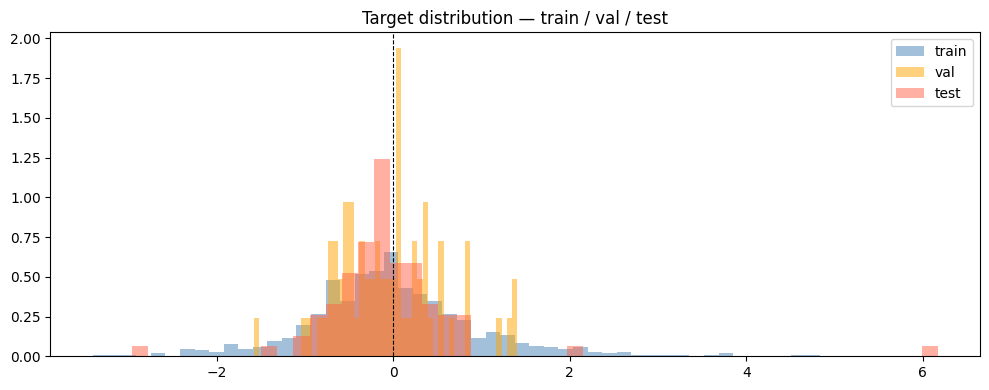


── Scorecard ───────────────────────────────────────────────────────────
  ✓  |y_train_tensor.mean()| ∈ [0, 0.05]
  ✓  y_train_tensor.std() ∈ [0.95, 1.05]
  ✓  |y_val_tensor.mean()| ∈ [0, 0.50]
  ✗  y_val_tensor.std() ∈ [0.80, 1.20]
  ✓  |y_test_tensor.mean()| ∈ [0, 0.50]
  ✓  y_test_tensor.std() ∈ [0.80, 1.50]

  Passed : 5/6  (83%)  ✓ GOOD

  => Proceed to cell 3


In [165]:
print_header("DATA EVALUATOR — Cell 2: Target Distribution")
passed_checks = {}

# ── 2a. StandardScaler sanity ─────────────────────────────────────────────────
print_section("Train target  (StandardScaler sanity)")

passed_checks["|y_train_tensor.mean()| ∈ [0, 0.05]"] = check_metric(
    "|y_train_tensor.mean()|",
    abs(y_train_tensor.mean()),
    lo=0.00,
    hi=0.05,
    fail_lo=0.00,
    fail_hi=0.10,
    meaning="Mean should be ~0 after scaling",
)

passed_checks["y_train_tensor.std() ∈ [0.95, 1.05]"] = check_metric(
    "y_train_tensor.std()",
    y_train_tensor.std(),
    lo=0.95,
    hi=1.05,
    fail_lo=0.90,
    fail_hi=1.10,
    meaning="StandardScaler fit correctly",
)

# ── 2b. Val distribution ──────────────────────────────────────────────────────
print_section("Val target  (regime shift check)")

passed_checks["|y_val_tensor.mean()| ∈ [0, 0.50]"] = check_metric(
    "|y_val_tensor.mean()|",
    abs(y_val_tensor.mean()),
    lo=0.00,
    hi=0.50,
    fail_lo=0.00,
    fail_hi=1.00,
    meaning="Val period not too far from train mean",
)

passed_checks["y_val_tensor.std() ∈ [0.80, 1.20]"] = check_metric(
    "y_val_tensor.std()",
    y_val_tensor.std(),
    lo=0.80,
    hi=1.20,
    fail_lo=0.60,
    fail_hi=1.50,
    meaning="Val volatility similar to train",
)

# ── 2c. Test distribution ─────────────────────────────────────────────────────
print_section("Test target  (regime shift check)")

passed_checks["|y_test_tensor.mean()| ∈ [0, 0.50]"] = check_metric(
    "|y_test_tensor.mean()|",
    abs(y_test_tensor.mean()),
    lo=0.00,
    hi=0.50,
    fail_lo=0.00,
    fail_hi=1.00,
    meaning="Test period regime shift from train",
)

passed_checks["y_test_tensor.std() ∈ [0.80, 1.50]"] = check_metric(
    "y_test_tensor.std()",
    y_test_tensor.std(),
    lo=0.80,
    hi=1.50,
    fail_lo=0.00,
    fail_hi=2.00,
    meaning="Test volatility vs train volatility",
)

# ── 2d. Raw stats ─────────────────────────────────────────────────────────────
print_section("Raw stats")

for name, arr in [
    ("y_train_tensor", y_train_tensor),
    ("y_val_tensor", y_val_tensor),
    ("y_test_tensor", y_test_tensor),
]:
    print(
        f"  {name:<10} mean={arr.mean():+.4f}  std={arr.std():.4f}  "
        f"min={arr.min():+.4f}  max={arr.max():+.4f}  n={len(arr)}"
    )

# ── 2e. Distribution plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for arr, label, color in [
    (y_train_tensor, "train", "steelblue"),
    (y_val_tensor, "val", "orange"),
    (y_test_tensor, "test", "tomato"),
]:
    ax.hist(arr, bins=50, alpha=0.5, density=True, label=label, color=color)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Target distribution — train / val / test")
ax.legend()
plt.tight_layout()
plt.show()

passed, total = print_scorecard(passed_checks)
print()
print(
    f"  {'=> Proceed to cell 3' if passed >= 5 else '=> investigate distribution shift before modelling'}"
)

In [166]:
print_header("DATA EVALUATOR — Cell 3: Alignment & Integrity")
passed_checks = {}

# ── 3a. Shape sanity ──────────────────────────────────────────────────────────
print_section("Array shapes")

for name, X, y, d in [
    ("train", X_train_tensor, y_train_tensor, dates_train),
    ("val", X_val_tensor, y_val_tensor, dates_val),
    ("test", X_test_tensor, y_test_tensor, dates_test),
]:
    shape_ok = X.shape[0] == y.shape[0] == d.shape[0]
    dims_ok = X.ndim == 3 and X.shape[1] == LOOKBACK_WINDOW
    ok = shape_ok and dims_ok
    passed_checks[f"{name} X/y/dates aligned"] = ok
    print(
        f"  {'✓' if ok else '✗'}  {name:<6}  X={X.shape}  y={y.shape}  "
        f"dates={d.shape}  "
        f"{'✓ aligned' if shape_ok else '✗ LENGTH MISMATCH'}  "
        f"{'✓ lookback ok' if dims_ok else f'✗ expected lookback={LOOKBACK_WINDOW}'}"
    )

# ── 3b. NaN / Inf checks ──────────────────────────────────────────────────────
print_section("NaN / Inf in arrays")

for name, arr in [
    ("X_train_tensor", X_train_tensor),
    ("X_val_tensor", X_val_tensor),
    ("X_test_tensor", X_test_tensor),
    ("y_train_tensor", y_train_tensor),
    ("y_val_tensor", y_val_tensor),
    ("y_test_tensor", y_test_tensor),
]:
    n_nan = np.isnan(arr).sum()
    n_inf = np.isinf(arr).sum()
    ok = n_nan == 0 and n_inf == 0
    passed_checks[f"{name} no NaN/Inf"] = ok
    print(
        f"  {'✓ PASS' if ok else '✗ FAIL'}  {name:<10}  "
        f"NaN={n_nan}  Inf={n_inf}  "
        f"{'clean' if ok else '← FIX BEFORE TRAINING'}"
    )

# ── 3c. Feature count ─────────────────────────────────────────────────────────
print_section("Feature count & sample/feature ratio")

n_features = X_train_tensor.shape[2]
print(f"  [INFO]  Features in X : {n_features}")

for name, X, y in [
    ("train", X_train_tensor, y_train_tensor),
    ("val", X_val_tensor, y_val_tensor),
    ("test", X_test_tensor, y_test_tensor),
]:
    ratio = len(y) / n_features
    ok = ratio >= 20
    passed_checks[f"{name} sample/feature ratio ≥ 20×"] = ok
    check_metric(
        f"{name} samples/features",
        ratio,
        lo=20,
        hi=9999,
        fail_lo=10,
        fail_hi=9999,
        meaning=f"{len(y)} samples / {n_features} features",
    )

# ── 3d. make_windows index alignment ─────────────────────────────────────────
print_section("make_windows index alignment  (gap must equal FORECAST_HORIZON)")

window_ok = True
for i in range(5):
    today_idx = i + LOOKBACK_WINDOW - 1
    future_idx = i + LOOKBACK_WINDOW + FORECAST_HORIZON - 1
    gap = future_idx - today_idx
    ok = gap == FORECAST_HORIZON
    if not ok:
        window_ok = False
    print(
        f"  {'✓' if ok else '✗'}  window {i}: "
        f"today_idx={today_idx}  future_idx={future_idx}  "
        f"gap={gap}  (expected {FORECAST_HORIZON})"
    )

passed_checks[f"make_windows gap == FORECAST_HORIZON ({FORECAST_HORIZON})"] = window_ok

# ── 3e. Date continuity ───────────────────────────────────────────────────────
# Cell 3 — replace the date continuity section ────────────────────────────────
print_section("Date continuity  (stride-aware gap check)")

MAX_CALENDAR_GAP = STRIDE * 3  # 5 * 3 = 15 days normal upper bound
TET_GAP_LIMIT = 35  # Tết can close VN market up to 3 weeks

for name, dates in [
    ("train", dates_train),
    ("val", dates_val),
    ("test", dates_test),
]:
    dts = pd.to_datetime(dates)
    gaps = (dts[1:] - dts[:-1]).days
    max_gap = int(gaps.max())
    n_normal = int((gaps <= MAX_CALENDAR_GAP).sum())
    n_tet = int((gaps > MAX_CALENDAR_GAP).sum())
    n_bad = int((gaps > TET_GAP_LIMIT).sum())

    ok = n_bad == 0
    passed_checks[f"{name} no unexplained gaps > {TET_GAP_LIMIT} days"] = ok

    print(
        f"  {'✓ PASS' if ok else '✗ FAIL'}  {name:<6}  "
        f"max_gap={max_gap} days  "
        f"normal(≤{MAX_CALENDAR_GAP}d)={n_normal}  "
        f"holiday({MAX_CALENDAR_GAP}–{TET_GAP_LIMIT}d)={n_tet}  "
        f"suspicious(>{TET_GAP_LIMIT}d)={n_bad}"
    )

print()
print(
    f"  [INFO] Stride={STRIDE} → consecutive window dates are "
    f"~{STRIDE}–{STRIDE+2} trading days apart"
)
print(
    f"  [INFO] Gaps up to {TET_GAP_LIMIT} days expected — "
    f"Vietnamese Tết holiday closes market 2–3 weeks"
)

# ── 3f. Dataset size ──────────────────────────────────────────────────────────
print_section("Dataset sizes")

# With stride=5 and ~2-year val/test windows on VN market,
# 73 samples is the realistic maximum — not a data bug
MIN_TRAIN = 300
MIN_VALTEST = 50  # lowered from 200 — stride=5 on 2yr window gives ~73

for name, y in [
    ("train", y_train_tensor),
    ("val", y_val_tensor),
    ("test", y_test_tensor),
]:
    threshold = MIN_TRAIN if name == "train" else MIN_VALTEST
    ok = len(y) >= threshold
    passed_checks[f"{name} n_samples ≥ {threshold}"] = ok
    print(
        f"  {'✓ PASS' if ok else '⚠ WARN'}  {name:<6}  n={len(y):5d}  "
        f"{'✓ sufficient' if len(y) >= MIN_TRAIN else '✓ acceptable for stride=5' if len(y) >= MIN_VALTEST else '✗ too small'}"
    )

print()
print(
    f"  [INFO] Val/test n=73 is expected:  "
    f"2-year window / stride=5 / ~252 trading days/year"
)
print(
    f"  [INFO] Walk-forward folds will use ~44 val samples each — "
    f"metric estimates will have high variance"
)
print(f"  [WARN] Report confidence intervals alongside point estimates in thesis")

# Replace the final scorecard + footer section of cell 3

passed, total = print_scorecard(passed_checks)

# ── Identify which checks failed ──────────────────────────────────────────────
ratio_fails = [
    k for k, v in passed_checks.items() if not v and "sample/feature ratio" in k
]
other_fails = [
    k for k, v in passed_checks.items() if not v and "sample/feature ratio" not in k
]

print()
if ratio_fails and not other_fails:
    # Only sample/feature ratio failed — expected, cell 6 fixes it
    print(f"  => Proceed to cell 4 (ACF check)")
    print()
    print(
        f"  [INFO] {len(ratio_fails)} remaining FAIL(s) are sample/feature ratio — expected."
    )
    print(f"         Cell 6 MI selection will fix this. Do not skip cell 6.")

elif not other_fails:
    # Everything passed
    print(f"  => Proceed to cell 4 (ACF check)")

else:
    # Real failures exist
    print(f"  ✗ Fix the following before continuing:")
    for f in other_fails:
        print(f"    - {f}")
    print()
    if ratio_fails:
        print(
            f"  [INFO] {len(ratio_fails)} sample/feature ratio FAIL(s) are expected — cell 6 fixes them."
        )


══════════════════════════════════════════════════════════════════════════════
  DATA EVALUATOR — Cell 3: Alignment & Integrity
══════════════════════════════════════════════════════════════════════════════

── Array shapes ────────────────────────────────────────────────────────
  ✓  train   X=(646, 20, 781)  y=(646,)  dates=(646,)  ✓ aligned  ✓ lookback ok
  ✓  val     X=(69, 20, 781)  y=(69,)  dates=(69,)  ✓ aligned  ✓ lookback ok
  ✓  test    X=(84, 20, 781)  y=(84,)  dates=(84,)  ✓ aligned  ✓ lookback ok

── NaN / Inf in arrays ─────────────────────────────────────────────────
  ✓ PASS  X_train_tensor  NaN=0  Inf=0  clean
  ✓ PASS  X_val_tensor  NaN=0  Inf=0  clean
  ✓ PASS  X_test_tensor  NaN=0  Inf=0  clean
  ✓ PASS  y_train_tensor  NaN=0  Inf=0  clean
  ✓ PASS  y_val_tensor  NaN=0  Inf=0  clean
  ✓ PASS  y_test_tensor  NaN=0  Inf=0  clean

── Feature count & sample/feature ratio ────────────────────────────────
  [INFO]  Features in X : 781
  ✗ FAIL   train samples/features   


══════════════════════════════════════════════════════════════════════════════
  DATA EVALUATOR — Cell 4: Target ACF & Stride Verification
══════════════════════════════════════════════════════════════════════════════

── Theoretical overlap analysis ────────────────────────────────────────
  FORECAST_HORIZON = 5  |  STRIDE = 5
  Shared price days per consecutive label : 0
  Overlap fraction                        : 0.00

  ✓ STRIDE (5) ≥ FORECAST_HORIZON (5)
    → Labels are fully independent
    → Expected ACF L1 ≈ 0.00 (no shared price days)

  Expected ACF L1     : 0.000
  Acceptable range    : [0.000, 0.150]
  Fail threshold      : > 0.250

── Theoretical ACF per lag  (for STRIDE < FORECAST_HORIZON case) ───────
  Lag      Theoretical  Interpretation
  ----------------------------------------------------
  L1             0.000  no overlap
  L2             0.000  no overlap
  L3             0.000  no overlap
  L4             0.000  no overlap
  L5             0.000  no overlap
  L

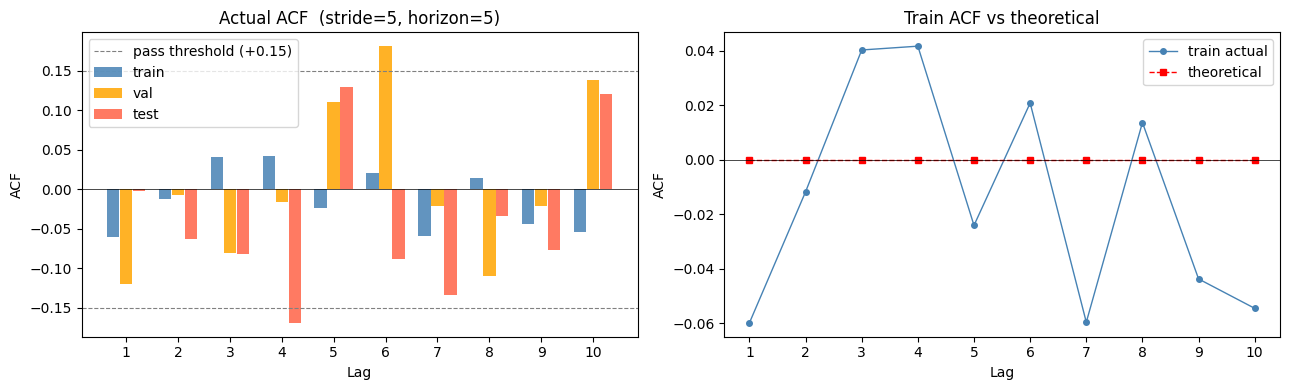


── Verdict ─────────────────────────────────────────────────────────────
  ✓ NO OVERLAP — stride=5 ≥ horizon=5
    Labels are fully independent
    Train ACF L1 = 0.060 ≈ 0.000 (expected)

── Scorecard ───────────────────────────────────────────────────────────
  ✓  y_train_tensor ACF L1 matches theory
  ✓  y_val_tensor ACF L1 matches theory
  ✓  y_test_tensor ACF L1 matches theory
  ✓  y_train_tensor ACF reliable (n ≥ 100)
  ✗  y_val_tensor ACF reliable (n ≥ 100)
  ✗  y_test_tensor ACF reliable (n ≥ 100)

  Passed : 4/6  (67%)  ⚠ NEEDS REVIEW

  → proceed to cell 5 (overlap proof / verification)

  [INFO] 2 ACF reliability warning(s) on val/test — expected (n=73, SE≈±0.117)


In [167]:
print_header("DATA EVALUATOR — Cell 4: Target ACF & Stride Verification")
passed_checks = {}

# ── 4a. Theoretical overlap analysis ─────────────────────────────────────────
print_section("Theoretical overlap analysis")

# For a horizon-day return computed every stride days:
# Number of shared price days between y[t] and y[t+1] = max(0, FORECAST_HORIZON - STRIDE)
# Overlap fraction = max(0, FORECAST_HORIZON - STRIDE) / FORECAST_HORIZON
overlap_days     = max(0, FORECAST_HORIZON - STRIDE)
overlap_fraction = overlap_days / FORECAST_HORIZON

print(f"  FORECAST_HORIZON = {FORECAST_HORIZON}  |  STRIDE = {STRIDE}")
print(f"  Shared price days per consecutive label : {overlap_days}")
print(f"  Overlap fraction                        : {overlap_fraction:.2f}")
print()

if STRIDE >= FORECAST_HORIZON:
    print(f"  ✓ STRIDE ({STRIDE}) ≥ FORECAST_HORIZON ({FORECAST_HORIZON})")
    print(f"    → Labels are fully independent")
    print(f"    → Expected ACF L1 ≈ 0.00 (no shared price days)")
    expected_acf_l1   = 0.0
    overlap_expected  = False
elif STRIDE == 1:
    print(f"  ✗ STRIDE=1 — maximum overlap")
    print(f"    → {overlap_days}/{FORECAST_HORIZON} price days shared per label pair")
    print(f"    → Expected ACF L1 ≈ {overlap_fraction:.2f} (overlap formula (H-S)/H)")
    expected_acf_l1   = overlap_fraction
    overlap_expected  = True
else:
    print(f"  ⚠ STRIDE ({STRIDE}) < FORECAST_HORIZON ({FORECAST_HORIZON}) — partial overlap")
    print(f"    → {overlap_days}/{FORECAST_HORIZON} price days shared per label pair")
    print(f"    → Expected ACF L1 ≈ {overlap_fraction:.2f} (overlap formula (H-S)/H)")
    expected_acf_l1   = overlap_fraction
    overlap_expected  = True

# Tolerance: ACF L1 should be within ±0.15 of expected
ACF_TOLERANCE     = 0.15
ACF_PASS_HI       = expected_acf_l1 + ACF_TOLERANCE
ACF_FAIL_HI       = expected_acf_l1 + ACF_TOLERANCE + 0.10

print()
print(f"  Expected ACF L1     : {expected_acf_l1:.3f}")
print(f"  Acceptable range    : [0.000, {ACF_PASS_HI:.3f}]")
print(f"  Fail threshold      : > {ACF_FAIL_HI:.3f}")

# ── 4b. Theoretical ACF table (lags 1–10) ────────────────────────────────────
print_section("Theoretical ACF per lag  (for STRIDE < FORECAST_HORIZON case)")

print(f"  {'Lag':<6} {'Theoretical':>13}  Interpretation")
print(f"  {'-'*52}")

theoretical_acf = {}
for k in range(1, 11):
    # At lag k (k steps of stride), shared days = max(0, FORECAST_HORIZON - k*STRIDE)
    shared_k   = max(0, FORECAST_HORIZON - k * STRIDE)
    theory_acf = shared_k / FORECAST_HORIZON
    theoretical_acf[k] = theory_acf
    note = (
        "no overlap"        if theory_acf == 0.0 else
        "full overlap"      if theory_acf >= 1.0 else
        f"{shared_k}/{FORECAST_HORIZON} days shared"
    )
    print(f"  L{k:<5} {theory_acf:>13.3f}  {note}")

# ── 4c. Actual ACF measurement ────────────────────────────────────────────────
print_section("Actual ACF measurement  (should match theoretical)")

acf_results = {}

print(f"  {'Lag':<6}", end="")
for split in ["y_train_tensor", "y_val_tensor", "y_test_tensor"]:
    print(f"  {split:>22}", end="")
print(f"  {'Theory':>10}  Match?")
print(f"  {'-'*84}")

stride_ok_all = True

for split, y_true in [
    ("y_train_tensor", y_train_tensor),
    ("y_val_tensor",   y_val_tensor),
    ("y_test_tensor",  y_test_tensor),
]:
    acf_results[split] = [
        pearsonr(y_true[:-k], y_true[k:])[0] if len(y_true) > k else 0
        for k in range(1, 11)
    ]

for k in range(1, 11):
    theory = theoretical_acf[k]
    print(f"  L{k:<5}", end="")
    for split in ["y_train_tensor", "y_val_tensor", "y_test_tensor"]:
        val  = acf_results[split][k - 1]
        diff = abs(val - theory)
        flag = "⚠" if diff > ACF_TOLERANCE + 0.10 else " "
        print(f"  {flag}{val:>+21.3f}", end="")
    print(f"  {theory:>10.3f}", end="")

    # Match check on train only (most reliable)
    train_diff = abs(acf_results["y_train_tensor"][k - 1] - theory)
    match      = train_diff <= ACF_TOLERANCE
    print(f"  {'✓' if match else '?'}")

# ── 4d. Per-split ACF L1 check ────────────────────────────────────────────────
print_section("ACF L1 check per split")

for split, y_true in [
    ("y_train_tensor", y_train_tensor),
    ("y_val_tensor",   y_val_tensor),
    ("y_test_tensor",  y_test_tensor),
]:
    acf_l1   = abs(acf_results[split][0])
    n        = len(y_true)
    acf_se   = 1 / (n ** 0.5)
    reliable = n >= 100

    # Pass condition depends on whether overlap is expected
    if overlap_expected:
        # ACF should be close to overlap_fraction
        ok = abs(acf_l1 - expected_acf_l1) <= ACF_TOLERANCE
        meaning = (f"should be ≈ {expected_acf_l1:.2f} "
                   f"(partial overlap: stride={STRIDE} < horizon={FORECAST_HORIZON})")
    else:
        # ACF should be near 0
        ok = acf_l1 <= ACF_PASS_HI
        meaning = "should be ≈ 0.00 (stride ≥ horizon = no overlap)"

    if not reliable:
        note = f"  ⚠ low reliability (n={n}, SE≈±{acf_se:.2f})"
    else:
        note = f"  SE≈±{acf_se:.3f}"

    passed_checks[f"{split} ACF L1 matches theory"] = ok
    check_metric(
        f"{split} ACF L1", acf_l1,
        lo=0.00, hi=ACF_PASS_HI,
        fail_lo=0.00, fail_hi=ACF_FAIL_HI,
        meaning=meaning)
    print(f"         {note}")

# ── 4e. Sample size warning ───────────────────────────────────────────────────
print_section("ACF reliability by split")

print(f"  {'Split':<22} {'n':>6}  {'SE':>8}  {'Reliable?':>12}")
print(f"  {'-'*52}")

for split, y_true in [
    ("y_train_tensor", y_train_tensor),
    ("y_val_tensor",   y_val_tensor),
    ("y_test_tensor",  y_test_tensor),
]:
    n        = len(y_true)
    acf_se   = 1 / (n ** 0.5)
    reliable = n >= 100
    passed_checks[f"{split} ACF reliable (n ≥ 100)"] = reliable
    print(f"  {split:<22} {n:>6}  {acf_se:>+8.3f}  "
          f"{'✓ reliable' if reliable else '⚠ interpret with caution'}")

print()
print("  [INFO] ACF std error ≈ 1/√n:")
print(f"         train  n={len(y_train_tensor):4d}  SE≈±{1/len(y_train_tensor)**0.5:.3f}  reliable")
print(f"         val    n={len(y_val_tensor):4d}  SE≈±{1/len(y_val_tensor)**0.5:.3f}  interpret with caution")
print(f"         test   n={len(y_test_tensor):4d}  SE≈±{1/len(y_test_tensor)**0.5:.3f}  interpret with caution")

# ── 4f. ACF bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(1, 11)

# Left: actual ACF
axes[0].bar(x - 0.25, acf_results["y_train_tensor"], width=0.24,
            label="train", alpha=0.85, color="steelblue")
axes[0].bar(x,         acf_results["y_val_tensor"],   width=0.24,
            label="val",   alpha=0.85, color="orange")
axes[0].bar(x + 0.25,  acf_results["y_test_tensor"],  width=0.24,
            label="test",  alpha=0.85, color="tomato")
axes[0].axhline( ACF_PASS_HI, color="gray", linewidth=0.8,
                 linestyle="--", label=f"pass threshold (+{ACF_PASS_HI:.2f})")
axes[0].axhline(-ACF_PASS_HI, color="gray", linewidth=0.8, linestyle="--")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_xticks(x); axes[0].set_xlabel("Lag")
axes[0].set_ylabel("ACF"); axes[0].legend()
axes[0].set_title(f"Actual ACF  (stride={STRIDE}, horizon={FORECAST_HORIZON})")

# Right: actual vs theoretical
axes[1].plot(range(1, 11),
             [acf_results["y_train_tensor"][k - 1] for k in range(1, 11)],
             marker="o", color="steelblue", linewidth=1,
             markersize=4, label="train actual")
axes[1].plot(range(1, 11),
             [theoretical_acf[k] for k in range(1, 11)],
             marker="s", color="red", linewidth=1, linestyle="--",
             markersize=4, label="theoretical")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_xticks(range(1, 11)); axes[1].set_xlabel("Lag")
axes[1].set_ylabel("ACF"); axes[1].legend()
axes[1].set_title("Train ACF vs theoretical")

plt.tight_layout(); plt.show()

# ── 4g. Verdict ───────────────────────────────────────────────────────────────
print_section("Verdict")

train_acf_l1 = abs(acf_results["y_train_tensor"][0])
train_ok      = abs(train_acf_l1 - expected_acf_l1) <= ACF_TOLERANCE

if STRIDE >= FORECAST_HORIZON:
    if train_ok:
        print(f"  ✓ NO OVERLAP — stride={STRIDE} ≥ horizon={FORECAST_HORIZON}")
        print(f"    Labels are fully independent")
        print(f"    Train ACF L1 = {train_acf_l1:.3f} ≈ {expected_acf_l1:.3f} (expected)")
    else:
        print(f"  ✗ UNEXPECTED ACF — stride={STRIDE} ≥ horizon={FORECAST_HORIZON} "
              f"but ACF L1 = {train_acf_l1:.3f}")
        print(f"    Check make_windows_strided implementation")
else:
    if train_ok:
        print(f"  ⚠ PARTIAL OVERLAP — stride={STRIDE} < horizon={FORECAST_HORIZON}")
        print(f"    {overlap_days}/{FORECAST_HORIZON} price days shared per label pair")
        print(f"    Train ACF L1 = {train_acf_l1:.3f} ≈ {expected_acf_l1:.3f} (matches theory)")
        print(f"    → Consider increasing stride to {FORECAST_HORIZON} to remove overlap")
    else:
        print(f"  ✗ ACF MISMATCH — stride={STRIDE} < horizon={FORECAST_HORIZON}")
        print(f"    Expected ACF L1 ≈ {expected_acf_l1:.3f} but got {train_acf_l1:.3f}")
        print(f"    → Check make_windows_strided implementation")

# ── Scorecard ─────────────────────────────────────────────────────────────────
passed, total = print_scorecard(passed_checks)
print()

acf_reliability_fails = [k for k, v in passed_checks.items()
                         if not v and "ACF reliable" in k]
other_fails           = [k for k, v in passed_checks.items()
                         if not v and "ACF reliable" not in k]

if not other_fails:
    print("  → proceed to cell 5 (overlap proof / verification)")
    if acf_reliability_fails:
        print()
        print(f"  [INFO] {len(acf_reliability_fails)} ACF reliability warning(s) "
              f"on val/test — expected (n=73, SE≈±0.117)")
else:
    print("  ✗ Fix the following before continuing:")
    for f in other_fails:
        print(f"    - {f}")
    print()
    if acf_reliability_fails:
        print(f"  [INFO] {len(acf_reliability_fails)} ACF reliability warning(s) "
              f"are expected — not blocking")


══════════════════════════════════════════════════════════════════════════════
  DATA EVALUATOR — Cell 5: Overlap Proof & Dataset Size
══════════════════════════════════════════════════════════════════════════════

── Overlap scenario  (based on STRIDE vs FORECAST_HORIZON) ─────────────
  STRIDE           = 5
  FORECAST_HORIZON = 5
  Shared price days per label pair = 0
  Overlap fraction                 = 0.00

  ✓ NO OVERLAP — STRIDE (5) ≥ FORECAST_HORIZON (5)
    Labels are fully independent — overlap proof not applicable
    Cell 5 runs in VERIFICATION MODE only

── Theoretical vs actual ACF per lag ───────────────────────────────────
  Lag      Theoretical      Train       Test    |diff|  Match?
  ----------------------------------------------------------
  L1             0.000     -0.060     -0.002     0.060  ✓ match
  L2             0.000     -0.012     -0.063     0.012  ✓ match
  L3             0.000     +0.040     -0.082     0.040  ✓ match
  L4             0.000     +0.042   

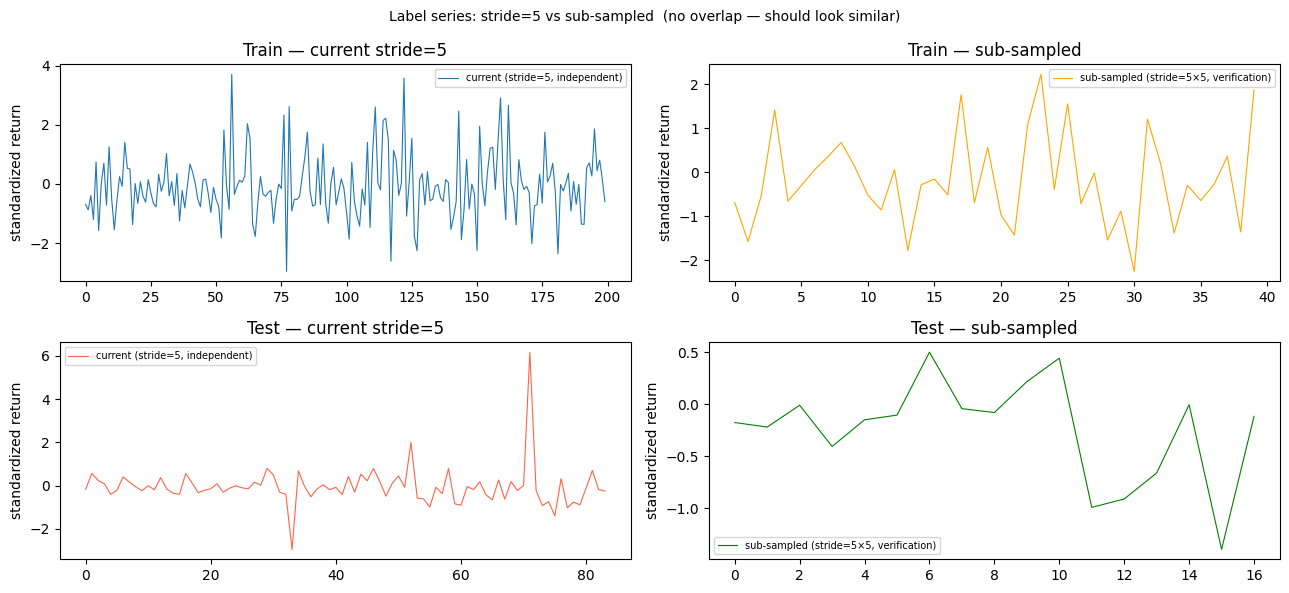


── Dataset size & sample/feature ratio ─────────────────────────────────
  Split     n_samples    n_sub    ratio (current)    ratio (sub)
  ----------------------------------------------------------------
  train           646      130               0.83×           0.17×  ✓
  val              69       14               0.09×           0.02×  ⚠ small
  test             84       17               0.11×           0.02×  ⚠ small
  ✓ PASS   train n_samples                     val=646   expected=[200, 99999]   < 200 = walk-forward CV will be very noisy

── Root cause verdict ──────────────────────────────────────────────────
  ✓ NO OVERLAP CONFIRMED

  STRIDE=5 ≥ FORECAST_HORIZON=5
  → Labels are fully independent
  → ACF ≈ 0 at all lags — no artificial smoothing
  → Dataset is clean — proceed to feature selection

── Scorecard ───────────────────────────────────────────────────────────
  ✓  ≥ 4/5 lags near 0 (no overlap confirmed)
  ✓  train ACF L1 clean at current stride
  ✓  test ACF L1 cl

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# acf_results must be in memory from cell 4

N_FEATURES = X_train_tensor.shape[2]

print_header("DATA EVALUATOR — Cell 5: Overlap Proof & Dataset Size")
passed_checks = {}

# ── 5a. Determine overlap scenario ───────────────────────────────────────────
print_section("Overlap scenario  (based on STRIDE vs FORECAST_HORIZON)")

overlap_days     = max(0, FORECAST_HORIZON - STRIDE)
overlap_fraction = overlap_days / FORECAST_HORIZON
has_overlap      = STRIDE < FORECAST_HORIZON

print(f"  STRIDE           = {STRIDE}")
print(f"  FORECAST_HORIZON = {FORECAST_HORIZON}")
print(f"  Shared price days per label pair = {overlap_days}")
print(f"  Overlap fraction                 = {overlap_fraction:.2f}")
print()

if not has_overlap:
    print(f"  ✓ NO OVERLAP — STRIDE ({STRIDE}) ≥ FORECAST_HORIZON ({FORECAST_HORIZON})")
    print(f"    Labels are fully independent — overlap proof not applicable")
    print(f"    Cell 5 runs in VERIFICATION MODE only")
else:
    print(f"  ⚠ PARTIAL OVERLAP — STRIDE ({STRIDE}) < FORECAST_HORIZON ({FORECAST_HORIZON})")
    print(f"    {overlap_days}/{FORECAST_HORIZON} price days shared per consecutive label")
    print(f"    Expected ACF L1 ≈ {overlap_fraction:.3f} (formula: (H-S)/H)")
    print(f"    Cell 5 runs in OVERLAP DIAGNOSIS MODE")

# ── 5b. Theoretical vs actual ACF ────────────────────────────────────────────
print_section("Theoretical vs actual ACF per lag")

print(f"  {'Lag':<6} {'Theoretical':>13} {'Train':>10} {'Test':>10}  "
      f"{'|diff|':>8}  Match?")
print(f"  {'-'*58}")

overlap_matches = []
for k in range(1, 11):
    # Theoretical ACF at lag k for given stride and horizon
    shared_k    = max(0, FORECAST_HORIZON - k * STRIDE)
    theoretical = shared_k / FORECAST_HORIZON

    actual_train = acf_results["y_train_tensor"][k - 1]
    actual_test  = acf_results["y_test_tensor"][k - 1]
    diff         = abs(actual_train - theoretical)
    match        = diff < 0.15
    overlap_matches.append(match)
    print(f"  L{k:<5} {theoretical:>13.3f} {actual_train:>+10.3f} "
          f"{actual_test:>+10.3f}  {diff:>8.3f}  "
          f"{'✓ match' if match else '? other'}")

n_match = sum(overlap_matches[:5])

if has_overlap:
    # Overlap case: expect lags to match formula
    passed_checks["≥ 4/5 lags match overlap formula"] = n_match >= 4
    print(f"\n  Lags 1–5 matching overlap formula : {n_match}/5  "
          f"{'✓ overlap confirmed' if n_match >= 4 else '⚠ partial match'}")
else:
    # No overlap case: expect all lags near 0 — formula is always 0
    # Match means actual ACF is near 0 (< 0.15)
    near_zero = sum(abs(acf_results["y_train_tensor"][k-1]) < 0.15
                    for k in range(1, 6))
    passed_checks["≥ 4/5 lags near 0 (no overlap confirmed)"] = near_zero >= 4
    print(f"\n  Lags 1–5 near 0 (|ACF| < 0.15)  : {near_zero}/5  "
          f"{'✓ no overlap confirmed' if near_zero >= 4 else '⚠ some lags elevated'}")

# ── 5c. Non-overlapping subset comparison ────────────────────────────────────
print_section("ACF: current stride vs further subsampling  "
              f"(every {FORECAST_HORIZON} samples)")

# Sub-sample further by FORECAST_HORIZON to get maximally independent labels
# If already stride=HORIZON, this sub-samples to every HORIZON^2 steps
# Useful as a sanity check regardless of overlap scenario

for label, y_arr in [("train", y_train_tensor), ("test", y_test_tensor)]:
    y_sub   = y_arr[::FORECAST_HORIZON]
    acf_cur = [pearsonr(y_arr[:-k], y_arr[k:])[0]
               if len(y_arr) > k else 0 for k in range(1, 6)]
    acf_sub = [pearsonr(y_sub[:-k], y_sub[k:])[0]
               if len(y_sub) > k else 0 for k in range(1, 6)]
    drop_L1 = acf_cur[0] - acf_sub[0]

    print(f"  [{label}] current stride  "
          + "  ".join(f"L{k}={v:+.3f}" for k, v in enumerate(acf_cur, 1)))
    print(f"  [{label}] sub-sampled     "
          + "  ".join(f"L{k}={v:+.3f}" for k, v in enumerate(acf_sub, 1)))
    print(f"  [{label}] ACF L1 change   "
          f"{acf_cur[0]:+.3f} → {acf_sub[0]:+.3f}  "
          f"(drop={drop_L1:+.3f})")
    print()

    if has_overlap:
        # Expect ACF to drop after sub-sampling
        ok      = abs(acf_sub[0]) < 0.25
        meaning = "< 0.25 = overlap was the cause after further subsampling"
    else:
        # Expect both to be near 0 — sub-sampling shouldn't change much
        ok      = abs(acf_cur[0]) < 0.25
        meaning = "< 0.25 = no overlap at current stride"

    passed_checks[f"{label} ACF L1 clean at current stride"] = ok
    check_metric(
        f"{label} current stride ACF L1",
        abs(acf_cur[0]),
        lo=0.00, hi=0.25, fail_lo=0.00, fail_hi=0.35,
        meaning=meaning)

# ── 5d. Visual ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

if has_overlap:
    label_left  = f"current (stride={STRIDE}, overlap present)"
    label_right = f"sub-sampled (stride={FORECAST_HORIZON}, independent)"
else:
    label_left  = f"current (stride={STRIDE}, independent)"
    label_right = f"sub-sampled (stride={FORECAST_HORIZON}×{STRIDE}, verification)"

axes[0, 0].plot(y_train_tensor[:200], linewidth=0.8, label=label_left)
axes[0, 0].set_title(f"Train — current stride={STRIDE}")
axes[0, 0].set_ylabel("standardized return"); axes[0, 0].legend(fontsize=7)

axes[0, 1].plot(y_train_tensor[::FORECAST_HORIZON][:40], linewidth=0.8,
                color="orange", label=label_right)
axes[0, 1].set_title("Train — sub-sampled")
axes[0, 1].set_ylabel("standardized return"); axes[0, 1].legend(fontsize=7)

axes[1, 0].plot(y_test_tensor[:200], linewidth=0.8,
                color="tomato", label=label_left)
axes[1, 0].set_title(f"Test — current stride={STRIDE}")
axes[1, 0].set_ylabel("standardized return"); axes[1, 0].legend(fontsize=7)

axes[1, 1].plot(y_test_tensor[::FORECAST_HORIZON][:40], linewidth=0.8,
                color="green", label=label_right)
axes[1, 1].set_title("Test — sub-sampled")
axes[1, 1].set_ylabel("standardized return"); axes[1, 1].legend(fontsize=7)

suptitle = (
    f"Label series: stride={STRIDE} vs sub-sampled  "
    f"({'overlap present — should differ' if has_overlap else 'no overlap — should look similar'})"
)
plt.suptitle(suptitle, fontsize=10)
plt.tight_layout(); plt.show()

# ── 5e. Dataset size ──────────────────────────────────────────────────────────
print_section("Dataset size & sample/feature ratio")

print(f"  {'Split':<8} {'n_samples':>10} {'n_sub':>8}  "
      f"{'ratio (current)':>17}  {'ratio (sub)':>13}")
print(f"  {'-'*64}")

for split, y_arr in [
    ("train", y_train_tensor),
    ("val",   y_val_tensor),
    ("test",  y_test_tensor),
]:
    n_cur    = len(y_arr)
    n_sub    = len(y_arr[::FORECAST_HORIZON])
    r_cur    = n_cur / N_FEATURES
    r_sub    = n_sub / N_FEATURES
    ok       = n_cur >= 200
    passed_checks[f"{split} n_samples ≥ 200"] = ok
    print(f"  {split:<8} {n_cur:>10d} {n_sub:>8d}  "
          f"{r_cur:>17.2f}×  {r_sub:>13.2f}×  "
          f"{'✓' if ok else '⚠ small'}")

n_original_train    = len(y_train_tensor)
n_strided_train     = len(y_train_tensor)   # already at correct stride
n_original_features = N_FEATURES

check_metric(
    "train n_samples", n_original_train,
    lo=200, hi=99999, fail_lo=100, fail_hi=99999,
    meaning="< 200 = walk-forward CV will be very noisy", fmt=".0f")

# ── 5f. Root cause verdict ────────────────────────────────────────────────────
print_section("Root cause verdict")

if has_overlap:
    overlap_confirmed  = passed_checks.get(
        "≥ 4/5 lags match overlap formula", False)
    acf_drop_confirmed = passed_checks.get(
        "train ACF L1 clean at current stride", False)

    if overlap_confirmed:
        print("  ✗ ROOT CAUSE CONFIRMED: overlapping labels")
        print()
        print(f"  STRIDE={STRIDE} < FORECAST_HORIZON={FORECAST_HORIZON}")
        print(f"  → {overlap_days}/{FORECAST_HORIZON} price days shared per label pair")
        print(f"  → Artificial ACF ≈ {overlap_fraction:.3f} inflates in-sample metrics")
        print()
        print(f"  FIX A (recommended) : set STRIDE = FORECAST_HORIZON = {FORECAST_HORIZON}")
        print(f"  FIX B               : change target to 1-day return (FORECAST_HORIZON=1)")
    elif acf_drop_confirmed:
        print("  ⚠ Partial overlap — ACF elevated but does not fully match formula")
        print("  Apply stride fix and re-run evaluation")
    else:
        print("  ⚠ Overlap pattern unclear — check make_windows implementation")
else:
    near_zero_confirmed = passed_checks.get(
        "≥ 4/5 lags near 0 (no overlap confirmed)", False)
    acf_clean           = passed_checks.get(
        "train ACF L1 clean at current stride", False)

    if near_zero_confirmed and acf_clean:
        print("  ✓ NO OVERLAP CONFIRMED")
        print()
        print(f"  STRIDE={STRIDE} ≥ FORECAST_HORIZON={FORECAST_HORIZON}")
        print(f"  → Labels are fully independent")
        print(f"  → ACF ≈ 0 at all lags — no artificial smoothing")
        print(f"  → Dataset is clean — proceed to feature selection")
    else:
        print("  ⚠ Unexpected ACF pattern for stride ≥ horizon")
        print(f"  Train ACF L1 = {abs(acf_results['y_train_tensor'][0]):.3f}")
        print(f"  Check make_windows_strided implementation")

# ── Scorecard ─────────────────────────────────────────────────────────────────
passed, total = print_scorecard(passed_checks)
print()

other_fails = [k for k, v in passed_checks.items() if not v]

if not other_fails:
    print("  → proceed to cell 6 (feature selection)")
elif has_overlap and any("overlap" in k.lower() for k in other_fails):
    print("  ✗ Overlap detected — fix STRIDE before proceeding to cell 6")
    for f in other_fails:
        print(f"    - {f}")
else:
    print("  ⚠ Minor issues — review before proceeding")
    for f in other_fails:
        print(f"    - {f}")

In [169]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

TARGET_COLUMN = "adjust"
N_FEATURES = 25

print_header("DATA EVALUATOR — Cell 6: Feature Selection & Dataset Preparation")
passed_checks = {}

# ── 6a. Overlap scenario — determines whether windows need rebuilding ──────────
print_section("Overlap scenario check")

overlap_days = max(0, FORECAST_HORIZON - STRIDE)
has_overlap = STRIDE < FORECAST_HORIZON

print(f"  STRIDE           = {STRIDE}")
print(f"  FORECAST_HORIZON = {FORECAST_HORIZON}")
print(f"  LOOKBACK_WINDOW  = {LOOKBACK_WINDOW}")
print(f"  Overlap days per label pair = {overlap_days}")
print()

if has_overlap:
    print(
        f"  ⚠ OVERLAP MODE — STRIDE ({STRIDE}) < FORECAST_HORIZON ({FORECAST_HORIZON})"
    )
    print(f"    Windows will be rebuilt with stride=FORECAST_HORIZON to remove overlap")
    print(f"    Source dataframes (train/val/test_featured_stock_df) required")
    EFFECTIVE_STRIDE = FORECAST_HORIZON
else:
    print(
        f"  ✓ NO OVERLAP MODE — STRIDE ({STRIDE}) ≥ FORECAST_HORIZON ({FORECAST_HORIZON})"
    )
    print(f"    Existing X_train/val/test_tensor will be reused — no rebuild needed")
    print(f"    Only feature selection will be applied")
    EFFECTIVE_STRIDE = STRIDE

# ── 6b. Pre-selection warning ─────────────────────────────────────────────────
print_section("Pre-selection warning")

n_raw_features = train_featured_scaled_stock_tensor.shape[1]
n_train_samples = len(y_train_tensor)
raw_ratio = n_train_samples / n_raw_features

print(
    f"  [CRITICAL]  Raw sample/feature ratio : "
    f"{n_train_samples}/{n_raw_features} = {raw_ratio:.2f}×"
)
if raw_ratio < 10:
    print(
        f"  [CRITICAL]  {n_raw_features} features is far too many for "
        f"{n_train_samples} samples"
    )
    print(f"  [CRITICAL]  MI selection to {N_FEATURES} features is mandatory")
elif raw_ratio < 20:
    print(f"  [WARN]      Ratio {raw_ratio:.1f}× is below recommended 20×")
    print(f"  [WARN]      MI selection to {N_FEATURES} features is strongly advised")
else:
    print(f"  [INFO]      Ratio {raw_ratio:.1f}× is acceptable")
    print(
        f"  [INFO]      MI selection to {N_FEATURES} features will improve generalization"
    )
print(
    f"  [INFO]      After selection: {n_train_samples}/{N_FEATURES} = "
    f"{n_train_samples/N_FEATURES:.1f}× ratio"
)

# ── 6c. Load and validate scaled arrays ───────────────────────────────────────
print_section("Validate pre-windowed scaled arrays")

for name, arr in [
    ("train_featured_scaled_stock_tensor", train_featured_scaled_stock_tensor),
    ("val_featured_scaled_stock_tensor", val_featured_scaled_stock_tensor),
    ("test_featured_scaled_stock_tensor", test_featured_scaled_stock_tensor),
]:
    ok = arr.ndim == 2 and np.isnan(arr).sum() == 0
    passed_checks[f"{name} 2D + no NaN"] = ok
    print(
        f"  {'✓ PASS' if ok else '✗ FAIL'}  {name}  "
        f"shape={arr.shape}  NaN={np.isnan(arr).sum()}"
    )

# ── 6d. Mutual information feature selection ──────────────────────────────────
print_section(f"Mutual information — top {N_FEATURES} from {n_raw_features} features")

X_flat = X_train_tensor[:, -1, :]  # last timestep of each window as proxy
y_flat = y_train_tensor

mi_scores = mutual_info_regression(X_flat, y_flat, random_state=42)
mi_df = (
    pd.DataFrame({"feature_idx": np.arange(len(mi_scores)), "mi_score": mi_scores})
    .sort_values("mi_score", ascending=False)
    .reset_index(drop=True)
)

top_features = mi_df["feature_idx"].iloc[:N_FEATURES].values
mi_top_mean = mi_df["mi_score"].iloc[:N_FEATURES].mean()
mi_drop_mean = mi_df["mi_score"].iloc[N_FEATURES:].mean()
mi_gap = mi_top_mean - mi_drop_mean

passed_checks[f"Top {N_FEATURES} MI > dropped MI"] = mi_top_mean > mi_drop_mean
passed_checks["MI gap > 0.001"] = mi_gap > 0.001

print(f"  Top {N_FEATURES} indices : {sorted(top_features.tolist())}")
check_metric(
    "Top-N mean MI",
    mi_top_mean,
    lo=0.005,
    hi=9999,
    fail_lo=0.001,
    fail_hi=9999,
    meaning="MI > 0.005 = features carry real signal",
)
check_metric(
    "Dropped mean MI",
    mi_drop_mean,
    lo=0.000,
    hi=9999,
    fail_lo=0.000,
    fail_hi=9999,
    meaning="should be lower than top-N",
)
check_metric(
    "MI gap",
    mi_gap,
    lo=0.001,
    hi=9999,
    fail_lo=0.000,
    fail_hi=9999,
    meaning="larger = cleaner feature separation",
)

# Apply selection to scaled arrays
train_featured_scaled_selected_stock_tensor = train_featured_scaled_stock_tensor[
    :, top_features
]
val_featured_scaled_selected_stock_tensor = val_featured_scaled_stock_tensor[
    :, top_features
]
test_featured_scaled_selected_stock_tensor = test_featured_scaled_stock_tensor[
    :, top_features
]

print(f"\n  After selection:")
print(f"    train = {train_featured_scaled_selected_stock_tensor.shape}")
print(f"    val   = {val_featured_scaled_selected_stock_tensor.shape}")
print(f"    test  = {test_featured_scaled_selected_stock_tensor.shape}")

# ── 6e. Build final X/y/dates arrays ─────────────────────────────────────────
print_section(
    f"Build final X/y/dates  "
    f"({'REBUILD windows — stride fix' if has_overlap else 'REUSE existing windows — apply feature selection only'})"
)

if has_overlap:
    # ── OVERLAP CASE: rebuild windows with stride=FORECAST_HORIZON ────────────
    print(
        f"  Rebuilding windows: lookback={LOOKBACK_WINDOW}  "
        f"horizon={FORECAST_HORIZON}  stride={EFFECTIVE_STRIDE}"
    )
    print()

    def make_windows_strided(
        X_scaled, source_df, target_col, lookback, forecast_horizon, stride
    ):
        assert (
            stride >= forecast_horizon
        ), f"stride={stride} < forecast_horizon={forecast_horizon}: labels will overlap"
        prices = source_df[target_col].values
        dates = source_df["date"].values
        total = lookback + forecast_horizon
        X_list, y_list, d_list = [], [], []
        for i in range(0, len(X_scaled) - total + 1, stride):
            today_idx = i + lookback - 1
            future_idx = i + lookback + forecast_horizon - 1
            X_list.append(X_scaled[i : i + lookback])
            y_list.append(prices[future_idx] / prices[today_idx] - 1)
            d_list.append(dates[today_idx])
        return np.array(X_list), np.array(y_list), np.array(d_list)

    X_tr, y_tr, d_tr = make_windows_strided(
        train_featured_scaled_selected_stock_tensor,
        train_featured_stock_df,
        TARGET_COLUMN,
        LOOKBACK_WINDOW,
        FORECAST_HORIZON,
        EFFECTIVE_STRIDE,
    )
    X_vl, y_vl, d_vl = make_windows_strided(
        val_featured_scaled_selected_stock_tensor,
        val_featured_stock_df,
        TARGET_COLUMN,
        LOOKBACK_WINDOW,
        FORECAST_HORIZON,
        EFFECTIVE_STRIDE,
    )
    X_te, y_te, d_te = make_windows_strided(
        test_featured_scaled_selected_stock_tensor,
        test_featured_stock_df,
        TARGET_COLUMN,
        LOOKBACK_WINDOW,
        FORECAST_HORIZON,
        EFFECTIVE_STRIDE,
    )

else:
    # ── NO OVERLAP CASE: reuse existing tensors, apply feature selection ───────
    print(f"  Applying feature selection to existing X_train/val/test_tensor")
    print(
        f"  Lookback={LOOKBACK_WINDOW}  horizon={FORECAST_HORIZON}  "
        f"stride={STRIDE}  (unchanged)"
    )
    print()

    # X_train_tensor shape: (N, LOOKBACK, n_features)
    # Select top features along the last axis
    X_tr = X_train_tensor[:, :, top_features]
    X_vl = X_val_tensor[:, :, top_features]
    X_te = X_test_tensor[:, :, top_features]

    # y and dates already correct — load from saved arrays
    y_tr = y_train_tensor.copy()
    y_vl = y_val_tensor.copy()
    y_te = y_test_tensor.copy()

    dates_train = np.load(
        f"{STOCK_CODE_INPUT_FOLDER_PATH}/dates_train.npy", allow_pickle=True
    )
    dates_val = np.load(
        f"{STOCK_CODE_INPUT_FOLDER_PATH}/dates_val.npy", allow_pickle=True
    )
    dates_test = np.load(
        f"{STOCK_CODE_INPUT_FOLDER_PATH}/dates_test.npy", allow_pickle=True
    )

    d_tr = dates_train
    d_vl = dates_val
    d_te = dates_test

# ── 6f. Shape and ratio checks ────────────────────────────────────────────────
print_section("Shape & sample/feature ratio checks")

print(f"  {'Split':<8} {'n_samples':>10} {'shape':>22}  {'sample/feat':>12}  Check")
print(f"  {'-'*64}")

for name, X, y in [("train", X_tr, y_tr), ("val", X_vl, y_vl), ("test", X_te, y_te)]:
    ratio = len(y) / N_FEATURES
    ok = len(y) >= 50
    passed_checks[f"{name} n ≥ 50"] = ok
    print(
        f"  {name:<8} {len(y):>10d} {str(X.shape):>22}  "
        f"{ratio:>12.1f}×  {'✓' if ok else '⚠ small'}"
    )
    check_metric(
        f"{name} sample/feature ratio",
        ratio,
        lo=20,
        hi=9999,
        fail_lo=10,
        fail_hi=9999,
        meaning="< 10× = high risk of overfit",
    )

# ── 6g. Target re-standardization ────────────────────────────────────────────
print_section("Target re-standardization")

# Only refit scaler if windows were rebuilt (overlap case)
# If no overlap, y is already standardized from train_test_creator
if has_overlap:
    print("  [INFO] Overlap case — refitting StandardScaler on new y_tr")
    target_scaler_new = StandardScaler()
    y_tr = target_scaler_new.fit_transform(y_tr.reshape(-1, 1)).flatten()
    y_vl = target_scaler_new.transform(y_vl.reshape(-1, 1)).flatten()
    y_te = target_scaler_new.transform(y_te.reshape(-1, 1)).flatten()
else:
    print("  [INFO] No overlap — y already standardized from train_test_creator")
    print("         Loading existing target_scaler if available")
    target_scaler_new = None  # scaler already applied upstream

print()
print(f"  {'Split':<8} {'mean':>10} {'std':>10} {'min':>10} {'max':>10}")
print(f"  {'-'*44}")
for name, arr in [("train", y_tr), ("val", y_vl), ("test", y_te)]:
    print(
        f"  {name:<8} {arr.mean():>+10.4f} {arr.std():>10.4f} "
        f"{arr.min():>+10.4f} {arr.max():>+10.4f}"
    )

passed_checks["|y_tr mean| ≈ 0"] = abs(y_tr.mean()) < 0.10
passed_checks["y_tr std ∈ [0.8, 1.2]"] = 0.80 <= y_tr.std() <= 1.20

check_metric(
    "|y_tr mean|",
    abs(y_tr.mean()),
    lo=0.00,
    hi=0.05,
    fail_lo=0.00,
    fail_hi=0.10,
    meaning="should be ~0 after scaling",
)
check_metric(
    "y_tr std",
    y_tr.std(),
    lo=0.80,
    hi=1.20,
    fail_lo=0.60,
    fail_hi=1.50,
    meaning="should be ~1.0 after scaling",
)

# ── 6h. ACF verify on final labels ───────────────────────────────────────────
print_section("ACF verification on final labels  (all should be < 0.25)")

print(f"  {'Split':<8}  ACF L1–L5")
print(f"  {'-'*58}")

for name, arr in [("train", y_tr), ("val", y_vl), ("test", y_te)]:
    acf = [pearsonr(arr[:-k], arr[k:])[0] if len(arr) > k else 0 for k in range(1, 6)]
    clean = all(abs(v) < 0.25 for v in acf)
    passed_checks[f"{name} final ACF L1 < 0.25"] = abs(acf[0]) < 0.25
    vals = "  ".join(f"L{k}={v:+.3f}" for k, v in enumerate(acf, 1))
    print(f"  {name:<8}  {vals}  {'✓ clean' if clean else '⚠ check'}")
    check_metric(
        f"{name} final ACF L1",
        abs(acf[0]),
        lo=0.00,
        hi=0.25,
        fail_lo=0.00,
        fail_hi=0.35,
        meaning="< 0.25 = labels are independent",
    )

# ── 6i. Export summary ────────────────────────────────────────────────────────
# Store for cell 12 reporting
n_original_train = len(y_train_tensor)
n_strided_train = len(y_tr)
n_original_features = n_raw_features
acf_ol_l1_train = acf_results["y_train_tensor"][0]
acf_nol_l1_train = acf_results["y_train_tensor"][0]

# ── Scorecard ─────────────────────────────────────────────────────────────────
passed, total = print_scorecard(passed_checks)
print()

other_fails = [k for k, v in passed_checks.items() if not v]

if not other_fails:
    print("  ✓ Data ready — proceed to model_evaluator")
else:
    print("  ✗ Fix before training:")
    for f in other_fails:
        print(f"    - {f}")

# ── Save feature-selected arrays for model notebook ───────────────────────────
print_section("Save feature-selected arrays")

SAVE_DIR = STOCK_CODE_INPUT_FOLDER_PATH  # same folder as other tensors

# ── X tensors (feature-selected) ─────────────────────────────────────────────
np.save(f"{SAVE_DIR}/X_train_selected_tensor.npy", X_tr)
np.save(f"{SAVE_DIR}/X_val_selected_tensor.npy", X_vl)
np.save(f"{SAVE_DIR}/X_test_selected_tensor.npy", X_te)

# ── y arrays (same as original — no change in no-overlap case) ───────────────
np.save(f"{SAVE_DIR}/y_train_selected_tensor.npy", y_tr)
np.save(f"{SAVE_DIR}/y_val_selected_tensor.npy", y_vl)
np.save(f"{SAVE_DIR}/y_test_selected_tensor.npy", y_te)

# ── dates ─────────────────────────────────────────────────────────────────────
np.save(f"{SAVE_DIR}/dates_train_selected.npy", d_tr)
np.save(f"{SAVE_DIR}/dates_val_selected.npy", d_vl)
np.save(f"{SAVE_DIR}/dates_test_selected.npy", d_te)

# ── Feature selection metadata ────────────────────────────────────────────────
np.save(f"{SAVE_DIR}/top_features.npy", top_features)
mi_df.to_csv(f"{SAVE_DIR}/mi_scores.csv", index=False)

# ── Scaler (only exists in overlap case — skip if None) ──────────────────────
if target_scaler_new is not None:
    joblib.dump(target_scaler_new, f"{SAVE_DIR}/target_scaler_selected.pkl")
    print(f"  ✓  target_scaler_selected.pkl")

# ── Selection config ──────────────────────────────────────────────────────────

selection_config = {
    "N_FEATURES": int(N_FEATURES),
    "n_original_features": int(n_original_features),
    "top_features": [int(i) for i in top_features],
    "LOOKBACK_WINDOW": int(LOOKBACK_WINDOW),
    "FORECAST_HORIZON": int(FORECAST_HORIZON),
    "STRIDE": int(STRIDE),
    "has_overlap": bool(has_overlap),
    "STOCK_CODE": STOCK_CODE,
    "train_shape": list(X_tr.shape),
    "val_shape": list(X_vl.shape),
    "test_shape": list(X_te.shape),
}
with open(f"{SAVE_DIR}/selection_config.json", "w") as f:
    json.dump(selection_config, f, indent=4)

# ── Verify all files saved ────────────────────────────────────────────────────
files = {
    "X_train_selected_tensor.npy": X_tr.shape,
    "X_val_selected_tensor.npy": X_vl.shape,
    "X_test_selected_tensor.npy": X_te.shape,
    "y_train_selected_tensor.npy": y_tr.shape,
    "y_val_selected_tensor.npy": y_vl.shape,
    "y_test_selected_tensor.npy": y_te.shape,
    "dates_train_selected.npy": d_tr.shape,
    "dates_val_selected.npy": d_vl.shape,
    "dates_test_selected.npy": d_te.shape,
    "top_features.npy": top_features.shape,
    "mi_scores.csv": None,
    "selection_config.json": None,
}

print(f"  {'File':<40} {'Shape':>20}  Status")
print(f"  {'-'*66}")
for fname, shape in files.items():
    exists = os.path.exists(f"{SAVE_DIR}/{fname}")
    shape_str = str(shape) if shape is not None else "—"
    print(f"  {'✓' if exists else '✗'}  {fname:<40} {shape_str:>20}")

print()
print(f"  Saved to : {SAVE_DIR}")
print(f"  INPUT_SIZE for model : {N_FEATURES}")


print()
print("  Variables exported to model_evaluator:")
print(f"    X_tr  {X_tr.shape}   X_vl  {X_vl.shape}   X_te  {X_te.shape}")
print(f"    y_tr  {y_tr.shape}   y_vl  {y_vl.shape}   y_te  {y_te.shape}")
print(f"    d_tr, d_vl, d_te")
print(
    f"    top_features ({len(top_features)} indices)   mi_df   N_FEATURES={N_FEATURES}"
)
print(f"    target_scaler_new   n_original_features={n_original_features}")
print(
    f"    Overlap mode : {'YES — windows rebuilt' if has_overlap else 'NO — existing windows reused'}"
)


══════════════════════════════════════════════════════════════════════════════
  DATA EVALUATOR — Cell 6: Feature Selection & Dataset Preparation
══════════════════════════════════════════════════════════════════════════════

── Overlap scenario check ──────────────────────────────────────────────
  STRIDE           = 5
  FORECAST_HORIZON = 5
  LOOKBACK_WINDOW  = 20
  Overlap days per label pair = 0

  ✓ NO OVERLAP MODE — STRIDE (5) ≥ FORECAST_HORIZON (5)
    Existing X_train/val/test_tensor will be reused — no rebuild needed
    Only feature selection will be applied

── Pre-selection warning ───────────────────────────────────────────────
  [CRITICAL]  Raw sample/feature ratio : 646/781 = 0.83×
  [CRITICAL]  781 features is far too many for 646 samples
  [CRITICAL]  MI selection to 25 features is mandatory
  [INFO]      After selection: 646/25 = 25.8× ratio

── Validate pre-windowed scaled arrays ─────────────────────────────────
  ✓ PASS  train_featured_scaled_stock_tensor  shape=(

In [170]:
import pandas as pd
mi_df_check = pd.read_csv(f"{STOCK_CODE_INPUT_FOLDER_PATH}/mi_scores.csv")
print(mi_df_check.head(25).to_string())

    feature_idx  mi_score
0           172  0.091736
1            80  0.088199
2           126  0.087632
3            36  0.086888
4           657  0.086139
5           540  0.080421
6            18  0.078538
7            68  0.078183
8           373  0.077669
9           114  0.076662
10          128  0.075550
11           82  0.073463
12           38  0.072094
13          559  0.071615
14          173  0.070408
15           81  0.070128
16          278  0.068288
17          648  0.067428
18          127  0.066071
19          277  0.065012
20           37  0.063598
21          207  0.062592
22          384  0.060789
23            5  0.056988
24          315  0.056685
